### Análisis de Datos

In [2572]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2573]:
casas_dev_df = pd.read_csv("casas_dev.csv")
casas_test_df = pd.read_csv("casas_test.csv")


In [2574]:
print('shape = ', casas_dev_df.shape)
casas_dev_df.sample(7)

shape =  (900, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
137,560.0,sqft,1,0,15.0,618.0,40.711214,-74.005588,2.0
69,926.0,sqft,0,0,9.0,725.0,40.716371,-74.005129,2.0
351,1518.0,sqft,0,0,2.0,1210.0,40.707744,-74.004189,4.0
627,162.0,m2,1,1,NaN,337.0,-34.531375,-58.414459,5.0
429,40.0,m2,0,0,4.0,67.0,-34.597718,-58.345091,1.0
861,807.0,sqft,0,0,2.0,600.0,40.681920,-73.998435,2.0
239,201.0,m2,0,0,12.0,410.0,-34.606181,-58.389308,5.0


In [2575]:
print('shape = ', casas_test_df.shape)
casas_test_df.sample(7)

shape =  (100, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
67,67.0,m2,0,0,13.0,104.0,-34.566443,-58.313590,2.0
23,915.0,sqft,1,0,19.0,770.0,40.755180,-73.992292,2.0
78,101.0,m2,0,0,NaN,164.0,-34.613130,-58.301719,3.0
74,118.0,m2,1,0,7.0,230.0,-34.645930,-58.401218,4.0
63,79.0,m2,0,0,NaN,124.0,-34.632125,-58.444064,2.0
62,1023.0,sqft,0,0,NaN,747.0,40.689159,-74.007984,3.0
21,635.0,sqft,0,0,9.0,424.0,40.722805,-74.055818,2.0


In [2576]:
def valores_faltantes(df):
    print("\nValores faltantes por columna:")
    print(df.isna().sum())

def porcentajes_faltantes(df):
    total_filas = len(df)
    
    n_nan_age = df["age"].isna().sum()
    porcentaje_nan_age = (n_nan_age / total_filas) * 100
    
    n_nan_rooms = df["rooms"].isna().sum()
    porcentaje_nan_rooms = (n_nan_rooms / total_filas) * 100

    print(f"Valores NaN en 'age': {n_nan_age} sobre un total de {total_filas} filas ({porcentaje_nan_age:.2f}%)")
    print(f"Valores NaN en 'rooms': {n_nan_rooms} sobre un total de {total_filas} filas ({porcentaje_nan_rooms:.2f}%)")

valores_faltantes(casas_dev_df)
porcentajes_faltantes(casas_dev_df)



Valores faltantes por columna:
area            0
area_units      0
is_house        0
has_pool        0
age           130
price           0
lat             0
lon             0
rooms          72
dtype: int64
Valores NaN en 'age': 130 sobre un total de 900 filas (14.44%)
Valores NaN en 'rooms': 72 sobre un total de 900 filas (8.00%)


Dropear 14.44% y/o 8% de los datos por una feature faltante sería desperdiciar mucha información por lo que intentaremos estimar estos valores faltantes. Para eso, anaelicemos el resto de las features y sus correlaciones.

In [2577]:
valores_faltantes(casas_test_df)
porcentajes_faltantes(casas_test_df)


Valores faltantes por columna:
area           0
area_units     0
is_house       0
has_pool       0
age           16
price          0
lat            0
lon            0
rooms          4
dtype: int64
Valores NaN en 'age': 16 sobre un total de 100 filas (16.00%)
Valores NaN en 'rooms': 4 sobre un total de 100 filas (4.00%)


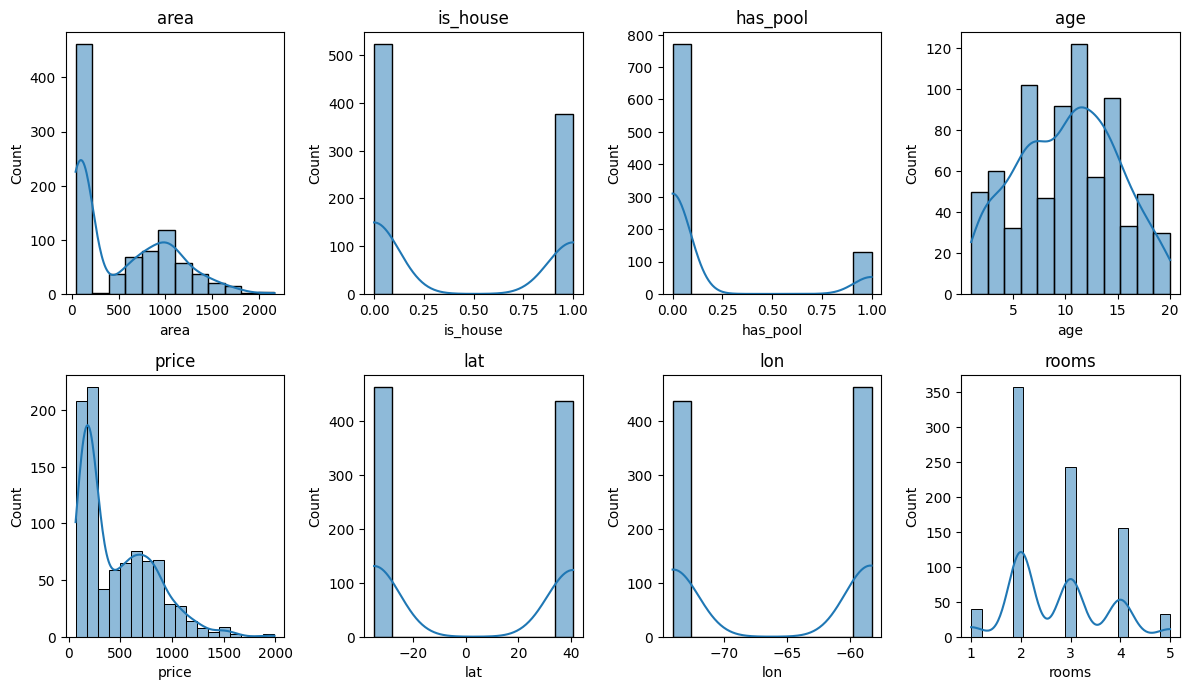

In [2578]:
def plot_distributions(df):
    to_plot = df.select_dtypes(include='number') # .columns.drop(['is_house', 'has_pool'])

    plt.figure(figsize=(12, 10))
    for i, col in enumerate(to_plot, 1):
        plt.subplot(3, 4, i)
        sns.histplot(df[col], kde=True)
        plt.title(col)
    plt.tight_layout()
    plt.show()
    
plot_distributions(casas_dev_df)

##### Revisión de unidades

In [2579]:
print(casas_dev_df['area_units'].value_counts())

area_units
m2      463
sqft    437
Name: count, dtype: int64


In [2580]:
def area_units_conversion(df):
    converted_df = df.copy()
    
    sqft_to_m2 = 1 / 10.76389999 # factor de conversión de sqft a m2

    converted_df.loc[converted_df['area_units'] == 'sqft', 'area'] *= sqft_to_m2

    converted_df.drop('area_units', axis=1, inplace=True)
    
    return converted_df    


In [2581]:
print(casas_test_df['area_units'].value_counts())

area_units
m2      53
sqft    47
Name: count, dtype: int64


In [2582]:
units_converted_dev_df = area_units_conversion(casas_dev_df)

In [2583]:
units_converted_test_df = area_units_conversion(casas_test_df)

Ahora sí podemos visualizar las distribuciones de dev

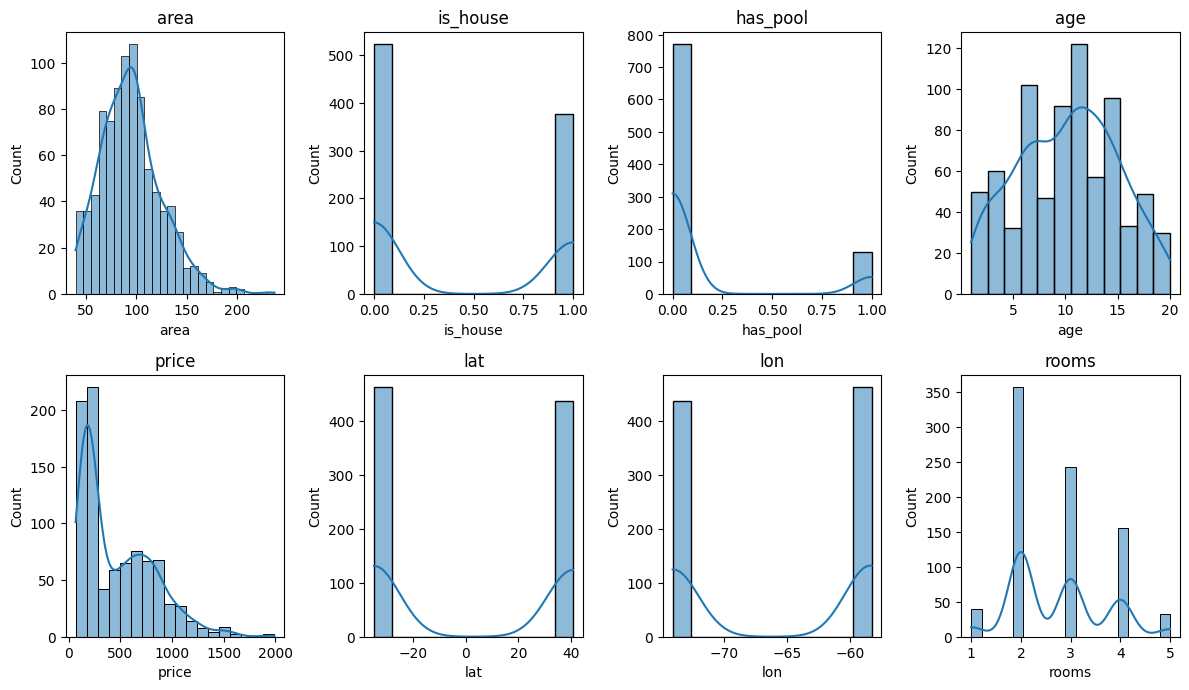

In [2584]:
plot_distributions(units_converted_dev_df)

ahora se puede visualizar mejor la distribución de área, que parece estar levemente sesgada a derecha si asumimos que los datos vienen de una distribución normal, o incluso parece una chi-cuadrado.

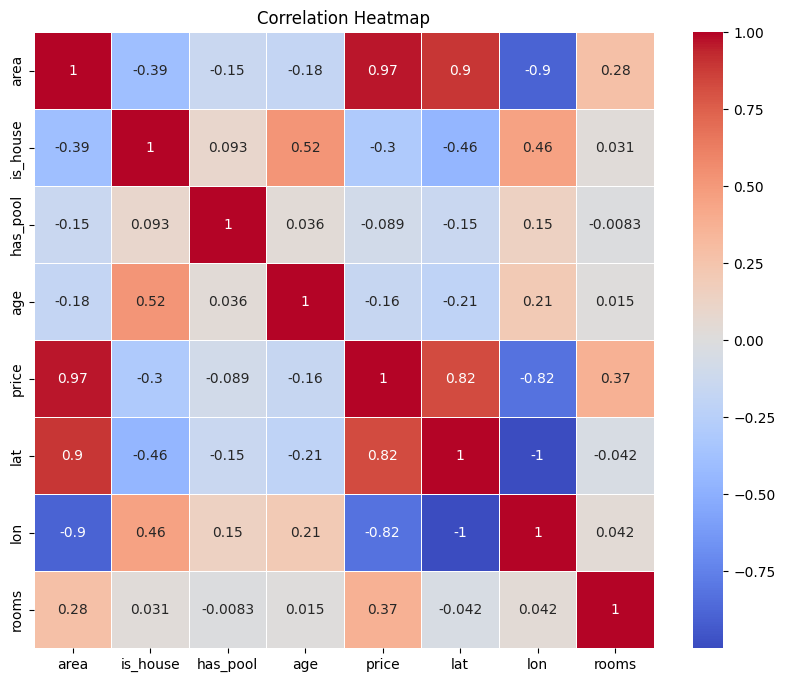

In [2585]:
def plot_correlation(df):
    df_numeric = df.select_dtypes(include=['number'])
    correlation_matrix = df_numeric.corr()

    plt.figure(figsize=(10, 8)) 
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()
    
plot_correlation(casas_dev_df)

##### estandarizamos o escalamos los datos según corresponde

hacemos estandarización (Z-score normalization) cuando la variable sigue una distribución aproximadamente normal
$$x' = \frac{x - \mu}{\sigma}$$

Y hacemos reescalado cuando cuando los datos no son normales
Una opción común es Min-Max Scaling:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Estandarizo:  
age (aproximadamente normal), rooms (discreta pero la estandarización ayuda)  
todavía no resolví los nulls así que aún no estandarizo.

Reescalo:   
lat y lon (son cíclicas y no son normales, tienen concentraciones en los extremos)  
lat_sin=sin(lat)  
lat_cos=cos(lat)  
lon_sin=sin(lon)  
lon_cos=cos(lon)  
donde sus valores están en [−1,1] de forma natural  
pero las variables van a estar muy correlacionadas por lo que después de esto hay que hacer PCA sobre estas

area y price están sesgadas a la derecha (colas largas)  
price = log(price + 1) (y hago un ajuste inverso después de la predicción)  
area = log(area + 1) y después estandarizar  
El log hace que los valores grandes no dominen el modelo y mejora la linealidad

No hago nada con las binarias: has_pool, is_house


In [2586]:
from funciones_auxiliares import normalize_var

In [ ]:
def scale_df(df, missing_values: bool=False):
    df_scaled = df.copy()
    
    if missing_values:
        df_scaled['age'] = normalize_var(df_scaled['age'])
        df_scaled['rooms'] = normalize_var(df_scaled['rooms'])
        
    else:
        df_scaled['lat_sin'] = np.sin(df_scaled['lat'])
        df_scaled['lat_cos'] = np.cos(df_scaled['lat'])
        df_scaled['lon_sin'] = np.sin(df_scaled['lon'])
        df_scaled['lon_cos'] = np.cos(df_scaled['lon'])

        df_scaled['area'] = np.log(df_scaled['area'] + 1)
        
        if 'price' in df_scaled.columns:
            df_scaled['price'] = np.log(df_scaled['price'] + 1)

        df_scaled['area'] = normalize_var(df_scaled['area'])

        # Las columnas binarias se mantienen igual -> is_house y has_pool no se transforman

        # Eliminamos lat y lon originales porque ya transformamos
        df_scaled = df_scaled.drop(columns=['lat', 'lon'])
    
    return df_scaled

casas_dev_transformed = scale_df(units_converted_dev_df)
casas_test_transformed = scale_df(units_converted_test_df)

casas_dev_transformed.head()

,area,is_house,has_pool,age,price,rooms,lat_sin,lat_cos,lon_sin,lon_cos
0,-1.306361,1,0,18.0,6.304449,2.0,0.160938,-0.986965,0.983769,0.179439
1,0.382622,0,0,9.0,6.633318,3.0,0.127517,-0.991836,0.990171,0.139863
2,-1.155246,0,0,7.0,6.142037,2.0,0.170012,-0.985442,0.979670,0.200616
3,1.061340,1,1,16.0,5.529429,4.0,0.042905,-0.999079,-0.956569,-0.291507
4,1.086152,0,0,8.0,6.871091,4.0,0.118106,-0.993001,0.987887,0.155172


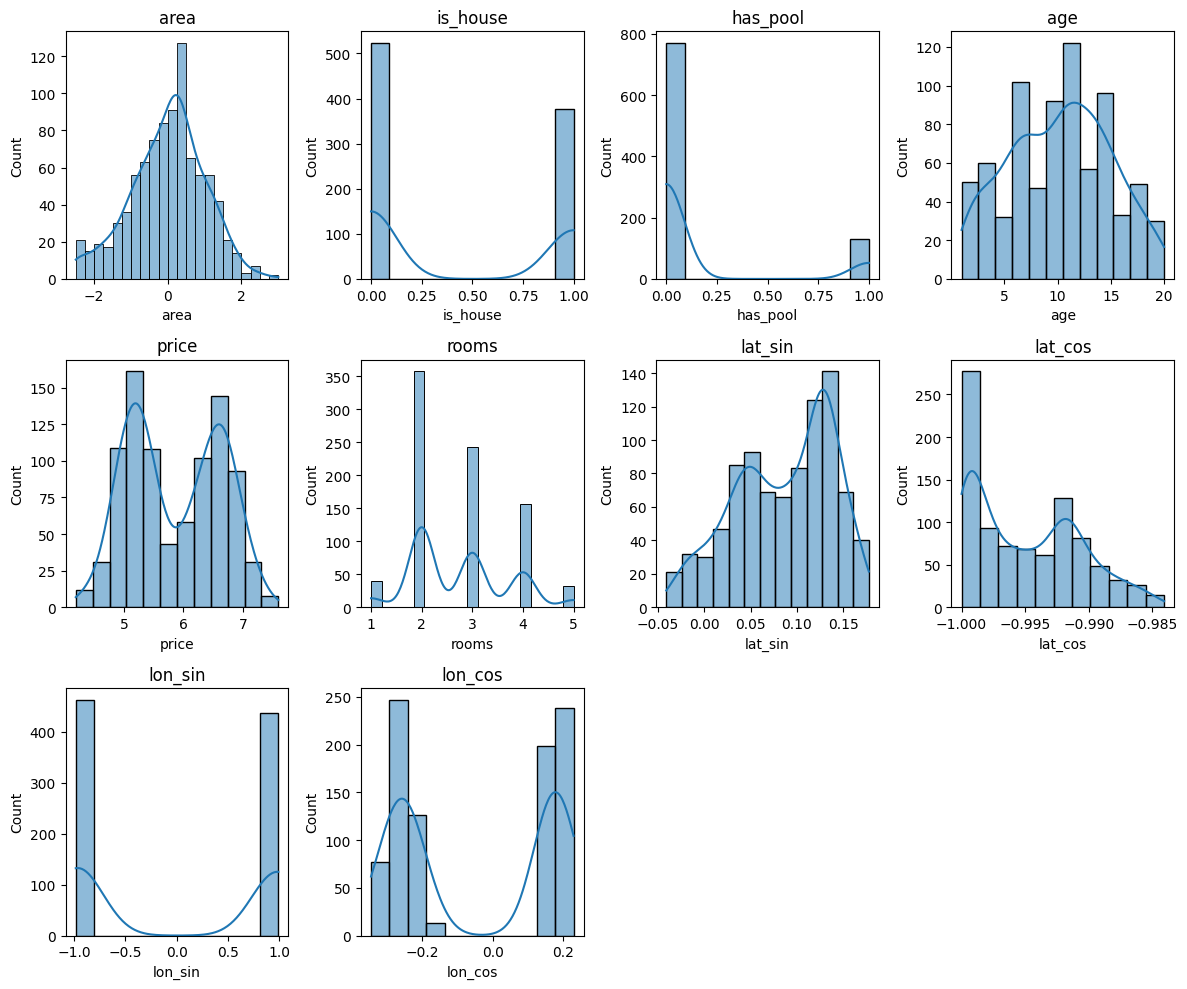

In [2588]:
plot_distributions(casas_dev_transformed)

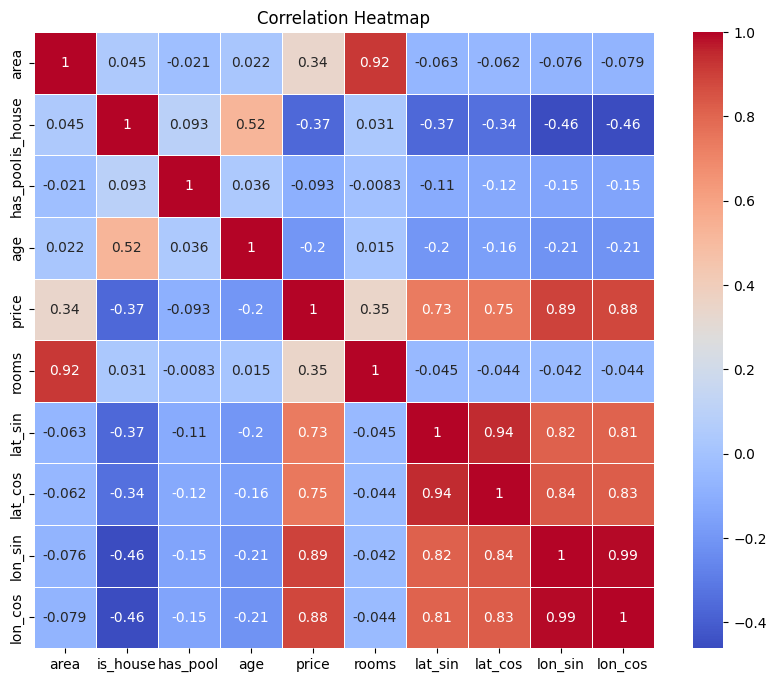

In [2589]:
plot_correlation(casas_dev_transformed)

In [2590]:
from funciones_auxiliares import pca_with_svd

In [2591]:
def pca_latlon(df):
    X_pca = df[['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos']].values
    Z, U_d, S_d, VT_d = pca_with_svd(X_pca, d=2)

    df['pca_latlon_1'] = Z[:, 0]
    df['pca_latlon_2'] = Z[:, 1]
    df = df.drop(columns=['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'])
    
    explained_variance = (S_d ** 2) / np.sum(S_d ** 2)
    print(f"Varianza explicada por cada componente: {explained_variance}")
    
    # la segunda componente no explica casi varianza, por lo que nos vamos a quedar con la primera
    df = df.drop(columns=['pca_latlon_2'])
    
    return df

casas_dev_transformed = pca_latlon(casas_dev_transformed)
casas_test_transformed = pca_latlon(casas_test_transformed)


Varianza explicada por cada componente: [[0.89163839 0.        ]
 [0.         0.10836161]]
Varianza explicada por cada componente: [[0.88687531 0.        ]
 [0.         0.11312469]]


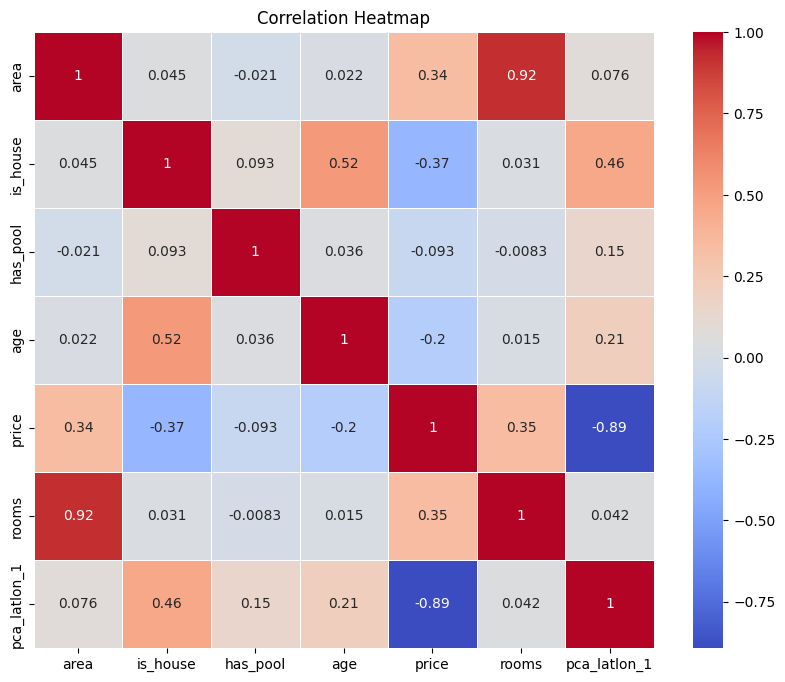

In [2592]:
plot_correlation(casas_dev_transformed)

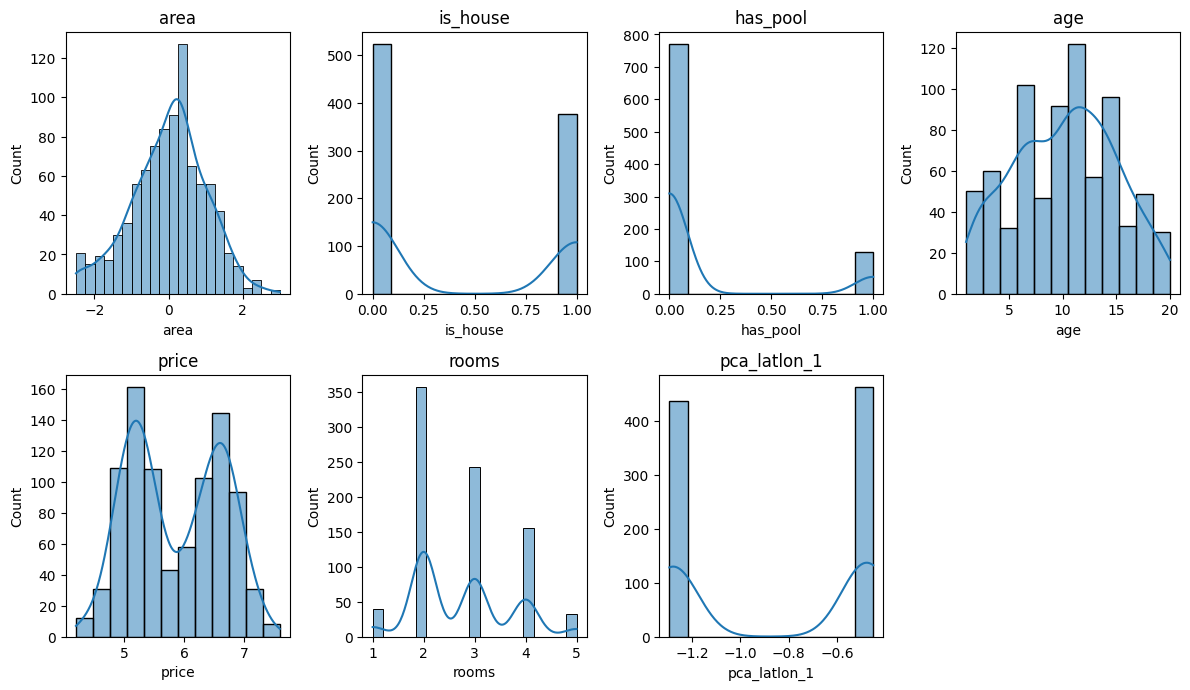

In [2593]:
plot_distributions(casas_dev_transformed)

#### Solucionamos ahora los problemas de nulls

##### Rooms

estimo la cantidad de rooms en base al área

visualizo la relación para ver qué regresión usar

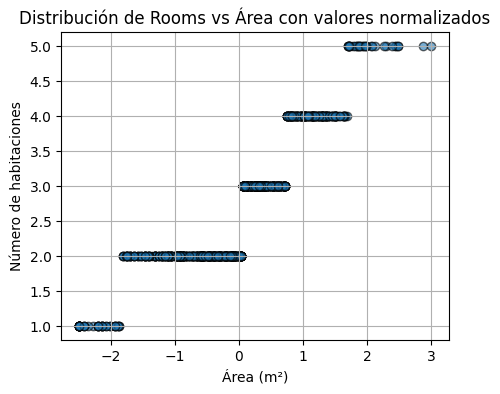

In [2594]:
def plot_rooms_vs_area(df, title: str):
    plt.figure(figsize=(5,4))
    plt.scatter(df["area"], df["rooms"], alpha=0.6, edgecolors="k")

    plt.xlabel("Área (m²)")
    plt.ylabel("Número de habitaciones")
    plt.title(f"Distribución de Rooms vs Área {title}")
    plt.grid(True)

    plt.show()

plot_rooms_vs_area(casas_dev_transformed, 'con valores normalizados')


In [2595]:
def datos_completos(df, to_drop):
    """Elimina filas con valores faltantes en las columnas especificadas."""
    return df.dropna(subset=to_drop)

def dividir_train_test(X, y, test_size=0.2, seed=42):
    """Divide los datos en conjunto de entrenamiento y prueba."""
    np.random.seed(seed)
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    split = int(X.shape[0] * (1 - test_size))
    
    X_train, X_test = X[indices[:split]], X[indices[split:]]
    y_train, y_test = y[indices[:split]], y[indices[split:]]
    
    return X_train, X_test, y_train, y_test


def softmax(z):
    """Función softmax para convertir logits en probabilidades."""
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True)) 
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def one_hot_encoding(y, num_classes):
    """Convierte la variable categórica y en one-hot encoding."""
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

def entrenar_logistica_multinomial(X, y, lr=0.1, epochs=10000):
    """Entrena un modelo de regresión logística multinomial con descenso de gradiente."""
    num_samples, num_features = X.shape
    num_classes = np.unique(y).size
    
    # Inicializar pesos y sesgos
    W = np.random.randn(num_features, num_classes) * 0.01
    b = np.zeros((1, num_classes))
    
    y_one_hot = one_hot_encoding(y, num_classes)

    for epoch in range(epochs):
        # Calcular logits y aplicar softmax
        logits = np.dot(X, W) + b
        probs = softmax(logits)
        
        # Calcular la pérdida (Entropía Cruzada)
        loss = -np.mean(y_one_hot * np.log(probs + 1e-8))  # epsilon para evitar log(0)
        
        # Gradientes
        grad_W = np.dot(X.T, (probs - y_one_hot)) / num_samples
        grad_b = np.mean(probs - y_one_hot, axis=0, keepdims=True)
        
        # Actualizar parámetros
        W -= lr * grad_W
        b -= lr * grad_b
        
        if epoch % 5000 == 0:
            print(f"Época {epoch}, Pérdida: {loss:.4f}")
    
    return W, b

def predecir(X, W, b):
    """Realiza predicciones con el modelo entrenado."""
    logits = np.dot(X, W) + b
    probs = softmax(logits)
    return np.argmax(probs, axis=1)  # Clase con mayor probabilidad

def precision(y_real, y_pred):
    """Calcula la precisión del modelo."""
    return np.mean(y_real == y_pred)


# ---- USO DEL MODELO ----

def predecir_rooms(df):
    
    # 1. Cargar los datos y limpiar
    datos = datos_completos(df, ['rooms'])

    # 2. Variables X (Área) e y (Rooms)
    X = datos[['area']].values
    y = datos['rooms'].values.astype(int)

    # Asegurar que las clases comiencen en 0
    y = y - np.min(y)

    # # 3. Normalizar X (manteniendo y sin normalizar)
    X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

    # 4. Dividir en train/test
    X_train, X_test, y_train, y_test = dividir_train_test(X, y)

    # 5. Entrenar el modelo
    W, b = entrenar_logistica_multinomial(X_train, y_train, lr=0.1, epochs=28694)

    # 6. Evaluar el modelo
    y_pred = predecir(X_test, W, b)
    accuracy = precision(y_test, y_pred)
    print(f"Precisión en el conjunto de prueba: {accuracy:.4f}")
    
    return W, b, X


def completar_valores_faltantes(df, W, b, X):
    """Completa los valores faltantes en la columna 'rooms' usando el modelo entrenado."""
    # 1. Filtrar filas con valores faltantes en "rooms"
    df_faltantes = df[df['rooms'].isna()].copy()
    
    # 2. Tomar X (area) de las filas faltantes
    X_faltantes = df_faltantes[['area']].values

    # 3. Normalizar X usando las mismas medias y desviaciones del entrenamiento
    X_faltantes = (X_faltantes - np.mean(X, axis=0)) / np.std(X, axis=0)

    # 4. Predecir los valores de "rooms"
    y_pred_faltantes = predecir(X_faltantes, W, b)

    # 5. Insertar los valores predichos en el dataframe original
    df.loc[df['rooms'].isna(), 'rooms'] = y_pred_faltantes

    print(f"{len(df_faltantes)} valores faltantes en 'rooms' completados.")
    return df

W_d, b_d, X_d = predecir_rooms(casas_dev_transformed)
casas_dev_rooms_complete = completar_valores_faltantes(casas_dev_transformed, W_d, b_d, X_d)

W_t, b_t, X_t = predecir_rooms(casas_test_transformed)
casas_test_rooms_complete = completar_valores_faltantes(casas_test_transformed, W_t, b_t, X_t)

Época 0, Pérdida: 0.3218
Época 5000, Pérdida: 0.0568
Época 10000, Pérdida: 0.0439
Época 15000, Pérdida: 0.0378
Época 20000, Pérdida: 0.0342
Época 25000, Pérdida: 0.0316
Precisión en el conjunto de prueba: 0.9759
72 valores faltantes en 'rooms' completados.
Época 0, Pérdida: 0.3205
Época 5000, Pérdida: 0.0485
Época 10000, Pérdida: 0.0361
Época 15000, Pérdida: 0.0298
Época 20000, Pérdida: 0.0257
Época 25000, Pérdida: 0.0229
Precisión en el conjunto de prueba: 0.9000
4 valores faltantes en 'rooms' completados.


##### Age

estimo las ages que faltan, con aprendizaje supervisado utilizando las features que más correlacion en módulo tienen con age $\rightarrow$ is_house, price, pca_latlon_1

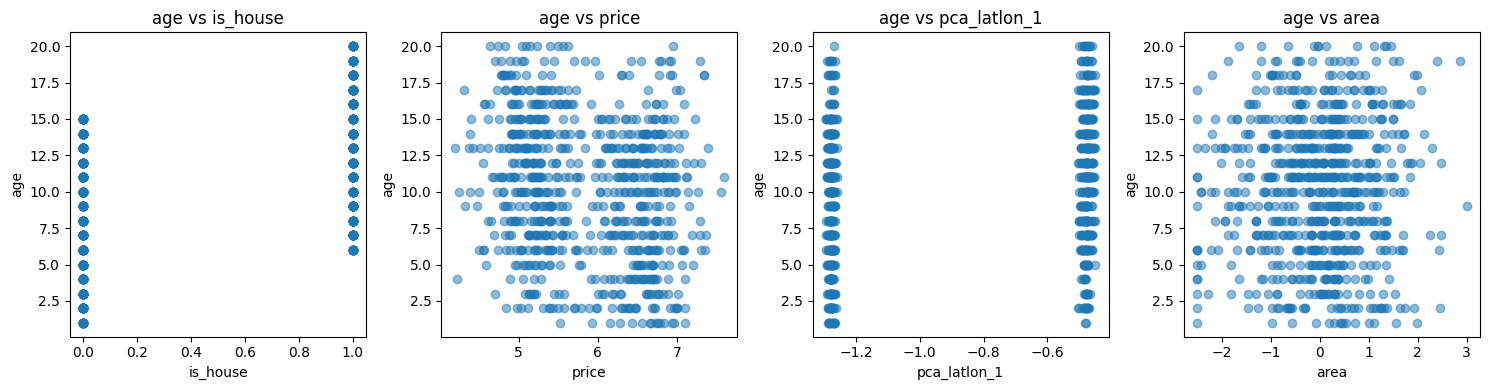

In [2596]:
def plot_age_vs(df):
    # Definir las columnas a graficar contra 'age'
    features = ["is_house", "price", "pca_latlon_1", "area"]

    # Crear la figura con subgráficos
    fig, axes = plt.subplots(1, len(features), figsize=(15, 4))

    for i, feature in enumerate(features):
        axes[i].scatter(df[feature], df["age"], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("age")
        axes[i].set_title(f"age vs {feature}")

    plt.tight_layout()
    plt.show()
    
plot_age_vs(casas_dev_rooms_complete)



In [2597]:

def agregar_sesgo(X):
    """Añade una columna de unos para el término de sesgo (intercepto)."""
    return np.c_[np.ones(X.shape[0]), X]

def generar_features_polinomicos(X, grado=1):
    """Genera términos polinómicos hasta el grado especificado."""
    if grado == 1:
        return X
    return np.hstack([X ** g for g in range(1, grado + 1)])

def dividir_train_test(df, features, test_size=0.2, seed=42):
    """Divide el dataset en train y test manteniendo valores completos."""
    df_completo = datos_completos(df, ['age'] + features)
    np.random.seed(seed)
    indices = np.random.permutation(len(df_completo))
    split_idx = int(len(df_completo) * (1 - test_size))
    return df_completo.iloc[indices[:split_idx]], df_completo.iloc[indices[split_idx:]]

def entrenar_regresion(df_train, features, grado=1):
    """Entrena una regresión polinómica usando la solución cerrada de mínimos cuadrados."""
    X = generar_features_polinomicos(df_train[features].values, grado)
    X = agregar_sesgo(X)
    y = df_train['age'].values
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def predecir(X, theta, grado=1):
    """Predice valores usando los coeficientes obtenidos."""
    X_poly = generar_features_polinomicos(X, grado)
    X_poly = agregar_sesgo(X_poly)
    return X_poly @ theta

def calcular_rmse(y_real, y_pred):
    """Calcula el error cuadrático medio (RMSE)."""
    return np.sqrt(np.mean((y_real - y_pred) ** 2))

def evaluar_modelo(df, features, grado=1):
    """Entrena el modelo y calcula el RMSE en train y test."""
    df_train, df_test = dividir_train_test(df, features)
    theta = entrenar_regresion(df_train, features, grado)

    y_train_pred = predecir(df_train[features].values, theta, grado)
    y_test_pred = predecir(df_test[features].values, theta, grado)

    rmse_train = calcular_rmse(df_train['age'].values, y_train_pred)
    rmse_test = calcular_rmse(df_test['age'].values, y_test_pred)

    print(f"Regresión Polinómica (grado {grado})")
    print(f"Train RMSE: {rmse_train:.4f}, Test RMSE: {rmse_test:.4f}")

    return theta

def completar_valores_faltantes(df, theta, features, grado=1):
    """Completa los valores faltantes en 'age' usando el modelo entrenado."""
    df_faltantes = df[df['age'].isna()].copy()

    X_faltantes = df_faltantes[features].values
    df.loc[df['age'].isna(), 'age'] = predecir(X_faltantes, theta, grado)
    print(f"{len(df_faltantes)} valores faltantes en 'age' completados.")

    return df

def estimar_ages_faltantes(df, features, grado=1):
    """Entrena el modelo y completa los valores faltantes de 'age'."""
    theta = evaluar_modelo(df, features, grado)
    return completar_valores_faltantes(df, theta, features, grado)

# Ejemplo de uso
features_seleccionadas = ['is_house', 'price', 'pca_latlon_1', 'area']

casas_dev_complete = estimar_ages_faltantes(casas_dev_rooms_complete, features_seleccionadas, grado=1)

casas_test_complete = estimar_ages_faltantes(casas_test_rooms_complete, features_seleccionadas, grado=1)


Regresión Polinómica (grado 1)
Train RMSE: 3.9484, Test RMSE: 3.9375
130 valores faltantes en 'age' completados.
Regresión Polinómica (grado 1)
Train RMSE: 4.2988, Test RMSE: 4.1938
16 valores faltantes en 'age' completados.


In [2598]:
casas_dev_complete= scale_df(casas_dev_complete, missing_values=True)
casas_test_complete = scale_df(casas_test_complete, missing_values=True)

In [2599]:

def guardar_csv(df, nombre_archivo):
    """Guarda un DataFrame en un archivo CSV."""
    df.to_csv(nombre_archivo, index=False)
    print(f"Dataset guardado como '{nombre_archivo}'.")

guardar_csv(casas_dev_complete, "casas_dev_corregido.csv")
guardar_csv(casas_test_complete, "casas_test_corregido.csv")


Dataset guardado como 'casas_dev_corregido.csv'.
Dataset guardado como 'casas_test_corregido.csv'.


In [ ]:
vivienda_Amanda_df = pd.read_csv("vivienda_Amanda.csv")
units_vivienda_Amanda_df = area_units_conversion(vivienda_Amanda_df)
vivienda_Amanda_scaled = scale_df(units_vivienda_Amanda_df)
vivienda_Amanda_transformed = pca_latlon(vivienda_Amanda_scaled)
vivienda_Amanda_scaled.head(1)
# vivienda_Amanda_scaled = scale_df(units_vivienda_Amanda_df, missing_values=True)



# guardar_csv(vivienda_Amanda_transformed, "vivienda_Amanda_corregido.csv")

IndexError: index 1 is out of bounds for axis 1 with size 1

##### Train y Validation

In [ ]:


def split_and_save(df, train_ratio=0.8, seed=42):
    np.random.seed(seed)
    shuffled_indices = np.random.permutation(len(df))
    
    train_size = int(len(df) * train_ratio)
    train_indices, val_indices = shuffled_indices[:train_size], shuffled_indices[train_size:]

    train_df = df.iloc[train_indices]
    val_df = df.iloc[val_indices]

    # Guardar en CSVs nuevos
    train_df.to_csv("casas_train.csv", index=False)
    val_df.to_csv("casas_validation.csv", index=False)
    
    print(f"Train set: {train_df.shape[0]} filas, Validation set: {val_df.shape[0]} filas")
    
    return train_df, val_df


train_df, val_df = split_and_save(casas_dev_complete)


Train set: 720 filas, Validation set: 180 filas
